# 🌊 Baseline Methods Evaluation

This notebook evaluates all baseline methods for ERA5 wave spectrum reconstruction:

1. **First Harmonic**: Uses only a1, b1 moments with cos/sin expansion
2. **Second Harmonic**: Uses a1, b1, a2, b2 moments with extended expansion  
3. **MEM (Maximum Entropy Method)**: Uses all moments with entropy maximization
4. **NDBC Method**: Alternative directional reconstruction approach

All methods will be compared using consistent evaluation metrics.

In [4]:
# Import required libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import warnings
import pandas as pd
from sklearn.metrics import r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
# Load processed data (from mlp.ipynb)
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30)
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30)
S2D_true = y_combined      # 2D spectra: (samples, 30, 24)

print(f"\nData shapes:")
print(f"S1D: {S1D.shape}")
print(f"S2D_true: {S2D_true.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")
print(f"b2: {b2.shape}")

# Check for any NaN values in loaded data  
print(f"\nNaN values check:")
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D_true: {np.isnan(S2D_true).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")

print(f"\n✅ Data loaded successfully: {S1D.shape[0]} samples")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504

Data shapes:
S1D: (9504, 30)
S2D_true: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)

NaN values check:
NaN values in S1D: 0
NaN values in S2D_true: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0

✅ Data loaded successfully: 9504 samples


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16016\1885104279.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [8]:
# Setup evaluation parameters
n_time, n_freq, n_dir = S2D_true.shape
direction_deg = 7.5 + 15 * np.arange(n_dir)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
direction_rad = np.deg2rad(direction_deg)
ddir = np.deg2rad(15.0)  # 15° spacing

print(f"Evaluation setup:")
print(f"  Time steps: {n_time}")
print(f"  Frequencies: {n_freq}")
print(f"  Directions: {n_dir}")
print(f"  Direction spacing: {np.rad2deg(ddir):.1f}°")

# Initialize results dictionary
results = {
    'method': [],
    'l2_error_mean': [],
    'l2_error_std': [],
    'mse': [],
    'mae': [],
    'r2_score': [],
    'correlation': [],
    'energy_conservation_error': [],
    'reconstruction_success_rate': []
}

def compute_evaluation_metrics(S_pred, S_true, method_name):
    """
    Compute comprehensive evaluation metrics for predicted spectrum
    """
    # Clean NaN values
    S_pred_clean = np.nan_to_num(S_pred, nan=0.0)
    S_true_clean = np.nan_to_num(S_true, nan=0.0)
    
    # L2 error per time step
    epsilon = 1e-10
    norm_true = np.linalg.norm(S_true_clean.reshape(n_time, -1), axis=1)
    norm_diff = np.linalg.norm((S_pred_clean - S_true_clean).reshape(n_time, -1), axis=1)
    relative_l2_error = norm_diff / (norm_true + epsilon)
    
    # MSE and MAE
    mse = np.mean((S_pred_clean - S_true_clean) ** 2)
    mae = np.mean(np.abs(S_pred_clean - S_true_clean))
    
    # R-squared
    S_true_flat = S_true_clean.flatten()
    S_pred_flat = S_pred_clean.flatten()
    r2 = r2_score(S_true_flat, S_pred_flat)
    
    # Correlation
    correlation = np.corrcoef(S_true_flat, S_pred_flat)[0, 1]
    
    # Energy conservation
    energy_true = np.mean(np.sum(S_true_clean, axis=(1, 2)))
    energy_pred = np.mean(np.sum(S_pred_clean, axis=(1, 2)))
    energy_conservation_error = np.abs(energy_pred - energy_true) / energy_true
    
    # Store results
    results['method'].append(method_name)
    results['l2_error_mean'].append(np.mean(relative_l2_error))
    results['l2_error_std'].append(np.std(relative_l2_error))
    results['mse'].append(mse)
    results['mae'].append(mae)
    results['r2_score'].append(r2)
    results['correlation'].append(correlation)
    results['energy_conservation_error'].append(energy_conservation_error)
    
    return relative_l2_error

print("\n✅ Evaluation framework setup complete")

Evaluation setup:
  Time steps: 9504
  Frequencies: 30
  Directions: 24
  Direction spacing: 15.0°

✅ Evaluation framework setup complete


## 1️⃣ First Harmonic Baseline

Uses only first-order directional moments (a1, b1) with the formula:
```
D(f,θ) = 1/(2π) × (1 + 2·a1·cos(θ) + 2·b1·sin(θ))
S(f,θ) = S_f(f) × D(f,θ)
```

In [9]:
# First Harmonic Baseline Method
print("=" * 60)
print("FIRST HARMONIC BASELINE")
print("=" * 60)

def compute_first_harmonic_spectrum(S1D, a1, b1, direction_rad, ddir):
    """
    Reconstruct 2D spectrum using first harmonic moments only
    """
    n_time, n_freq = S1D.shape
    n_dir = len(direction_rad)
    S_baseline = np.zeros((n_time, n_freq, n_dir))
    
    for t in range(n_time):
        for f in range(n_freq):
            S_f_val = S1D[t, f]
            a1_val = a1[t, f]
            b1_val = b1[t, f]
            
            if S_f_val > 1e-15:  # Only process non-zero frequencies
                # D = 1/(2π) × (1 + 2·a1·cos(θ) + 2·b1·sin(θ))
                D = (1.0 / (2 * np.pi)) * (1.0 + 2 * a1_val * np.cos(direction_rad) + 2 * b1_val * np.sin(direction_rad))
                
                # Ensure D is non-negative
                D = np.maximum(D, 0.0)
                
                # Renormalize D so that ∫ D dθ = 1
                D_integral = np.sum(D) * ddir
                if D_integral > 1e-10:
                    D = D / D_integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform distribution fallback
                
                # S(f,θ) = S_f(f) × D(f,θ)
                S_baseline[t, f, :] = S_f_val * D
            else:
                # No energy case - uniform distribution
                D = np.ones(n_dir) / n_dir
                S_baseline[t, f, :] = S_f_val * D
    
    return S_baseline



FIRST HARMONIC BASELINE


In [ ]:
# Compute first harmonic reconstruction
print("Computing first harmonic reconstruction...")
S_first_harmonic = compute_first_harmonic_spectrum(S1D, a1, b1, direction_rad, ddir)

print(f"✅ First harmonic reconstruction completed")
print(f"  Shape: {S_first_harmonic.shape}")
print(f"  Range: [{S_first_harmonic.min():.6e}, {S_first_harmonic.max():.6e}]")

# Evaluate first harmonic method
l2_errors_first = compute_evaluation_metrics(S_first_harmonic, S2D_true, "First Harmonic")
results['reconstruction_success_rate'].append(1.0)  # Always succeeds

print(f"\n📊 First Harmonic Results:")
print(f"  L2 Error: {results['l2_error_mean'][-1]:.6f} ± {results['l2_error_std'][-1]:.6f}")
print(f"  R²: {results['r2_score'][-1]:.6f}")
print(f"  Energy Conservation: {results['energy_conservation_error'][-1]:.6f}")

## 2️⃣ Second Harmonic Baseline

Extends first harmonic with second-order moments (a2, b2):
```
D(f,θ) = 1/(2π) × (1 + 2·a1·cos(θ) + 2·b1·sin(θ) + 2·a2·cos(2θ) + 2·b2·sin(2θ))
S(f,θ) = S_f(f) × D(f,θ)
```

In [10]:
# Second Harmonic Baseline Method  
print("=" * 60)
print("SECOND HARMONIC BASELINE")
print("=" * 60)

def compute_second_harmonic_spectrum(S1D, a1, b1, a2, b2, direction_rad, ddir):
    """
    Reconstruct 2D spectrum using first and second harmonic moments
    """
    n_time, n_freq = S1D.shape
    n_dir = len(direction_rad)
    S_baseline = np.zeros((n_time, n_freq, n_dir))
    
    for t in range(n_time):
        for f in range(n_freq):
            S_f_val = S1D[t, f]
            a1_val = a1[t, f]
            b1_val = b1[t, f]
            a2_val = a2[t, f]
            b2_val = b2[t, f]
            
            if S_f_val > 1e-15:  # Only process non-zero frequencies
                # Extended harmonic expansion
                # D = 1/(2π) × (1 + 2·a1·cos(θ) + 2·b1·sin(θ) + 2·a2·cos(2θ) + 2·b2·sin(2θ))
                D = (1.0 / (2 * np.pi)) * (
                    1.0 + 
                    2 * a1_val * np.cos(direction_rad) + 
                    2 * b1_val * np.sin(direction_rad) +
                    2 * a2_val * np.cos(2 * direction_rad) + 
                    2 * b2_val * np.sin(2 * direction_rad)
                )
                
                # Ensure D is non-negative
                D = np.maximum(D, 1e-10)  # Small positive minimum
                
                # Renormalize D so that ∫ D dθ = 1
                D_integral = np.sum(D) * ddir
                if D_integral > 1e-10:
                    D = D / D_integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform distribution fallback
                
                # S(f,θ) = S_f(f) × D(f,θ)
                S_baseline[t, f, :] = S_f_val * D
            else:
                # No energy case - uniform distribution
                D = np.ones(n_dir) / n_dir
                S_baseline[t, f, :] = S_f_val * D
    
    return S_baseline



SECOND HARMONIC BASELINE


In [ ]:
# Compute second harmonic reconstruction
print("Computing second harmonic reconstruction...")
S_second_harmonic = compute_second_harmonic_spectrum(S1D, a1, b1, a2, b2, direction_rad, ddir)

print(f"✅ Second harmonic reconstruction completed")
print(f"  Shape: {S_second_harmonic.shape}")
print(f"  Range: [{S_second_harmonic.min():.6e}, {S_second_harmonic.max():.6e}]")

# Evaluate second harmonic method
l2_errors_second = compute_evaluation_metrics(S_second_harmonic, S2D_true, "Second Harmonic")
results['reconstruction_success_rate'].append(1.0)  # Always succeeds

print(f"\n📊 Second Harmonic Results:")
print(f"  L2 Error: {results['l2_error_mean'][-1]:.6f} ± {results['l2_error_std'][-1]:.6f}")
print(f"  R²: {results['r2_score'][-1]:.6f}")
print(f"  Energy Conservation: {results['energy_conservation_error'][-1]:.6f}")

## 3️⃣ MEM (Maximum Entropy Method)

Uses entropy maximization with Lagrange multipliers to satisfy moment constraints:
```
D(θ) = exp(λ₁cos θ + λ₂sin θ + λ₃cos 2θ + λ₄sin 2θ) / Z
Subject to: ∫ D(θ)cos θ dθ = a₁, ∫ D(θ)sin θ dθ = b₁, etc.
```

In [11]:
# MEM (Maximum Entropy Method) Functions
print("=" * 60)
print("MEM (MAXIMUM ENTROPY METHOD)")
print("=" * 60)

def compute_mem_distribution(theta, lambdas):
    """
    Compute MEM directional distribution D(θ) = exp(F(θ)) / Z
    where F(θ) = λ₁cos θ + λ₂sin θ + λ₃cos 2θ + λ₄sin 2θ
    """
    l1, l2, l3, l4 = lambdas
    
    # F(θ) = λ₁cos θ + λ₂sin θ + λ₃cos 2θ + λ₄sin 2θ
    F = l1 * np.cos(theta) + l2 * np.sin(theta) + l3 * np.cos(2*theta) + l4 * np.sin(2*theta)
    
    # Prevent overflow by subtracting maximum
    F_max = np.max(F)
    exp_F = np.exp(F - F_max)
    
    # Normalize: D(θ) = exp(F(θ)) / ∫ exp(F(θ)) dθ
    ddir = theta[1] - theta[0] if len(theta) > 1 else 2*np.pi/len(theta)
    Z = np.sum(exp_F) * ddir
    
    return exp_F / Z

def compute_moments_from_distribution(theta, D, ddir):
    """Compute directional moments from distribution D(θ)"""
    a1_calc = np.sum(D * np.cos(theta)) * ddir
    b1_calc = np.sum(D * np.sin(theta)) * ddir  
    a2_calc = np.sum(D * np.cos(2*theta)) * ddir
    b2_calc = np.sum(D * np.sin(2*theta)) * ddir
    return np.array([a1_calc, b1_calc, a2_calc, b2_calc])

def moment_constraints(lambdas, theta, target_moments, ddir):
    """
    Constraint equations: computed moments - target moments = 0
    """
    D = compute_mem_distribution(theta, lambdas)
    computed_moments = compute_moments_from_distribution(theta, D, ddir)
    return computed_moments - target_moments

def solve_mem_parameters(a1_val, b1_val, a2_val, b2_val, theta, ddir, max_iter=100):
    """
    Solve for MEM parameters λ₁, λ₂, λ₃, λ₄ given target moments
    Returns: (lambdas, distribution, success)
    """
    target_moments = np.array([a1_val, b1_val, a2_val, b2_val])
    
    # Handle zero/small moments case
    if np.max(np.abs(target_moments)) < 1e-10:
        uniform_dist = np.ones(len(theta)) / len(theta)
        return np.zeros(4), uniform_dist, True  # Uniform distribution case
    
    # Initial guess: small random values (4 Lagrange multipliers for 4 moment constraints)
    initial_guess = np.random.normal(0, 0.1, 4)
    
    try:
        # Solve the nonlinear system
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            solution = fsolve(
                moment_constraints, 
                initial_guess, 
                args=(theta, target_moments, ddir),
                maxfev=max_iter * 4
            )
        
        # Verify solution quality
        residual = moment_constraints(solution, theta, target_moments, ddir)
        max_error = np.max(np.abs(residual))
        
        success = max_error < 1e-4
        
        if success:
            # Compute final distribution only once
            final_distribution = compute_mem_distribution(theta, solution)
            return solution, final_distribution, True
        else:
            # Return uniform distribution for failed case
            uniform_dist = np.ones(len(theta)) / len(theta)
            return solution, uniform_dist, False
        
    except Exception:
        uniform_dist = np.ones(len(theta)) / len(theta)
        return np.zeros(4), uniform_dist, False

print("✅ MEM functions defined")

MEM (MAXIMUM ENTROPY METHOD)
✅ MEM functions defined


In [11]:
# MEM Reconstruction
print("Computing MEM reconstruction...")

S_mem = np.zeros((n_time, n_freq, n_dir))

# Track solution statistics
total_cases = n_time * n_freq
solved_cases = 0
failed_cases = 0

print(f"Solving MEM parameters for {total_cases} cases...")

for t in range(n_time):
    if t % 1000 == 0:
        print(f"  Processing time step {t}/{n_time}")
    
    for f in range(n_freq):
        S_f_val = S1D[t, f]
        a1_val = a1[t, f]
        b1_val = b1[t, f]
        a2_val = a2[t, f]
        b2_val = b2[t, f]
        
        if S_f_val > 1e-15:  # Only process non-zero frequencies
            # Solve for MEM parameters and get distribution in one call
            lambdas, D, success = solve_mem_parameters(
                a1_val, b1_val, a2_val, b2_val, 
                direction_rad, ddir
            )
            
            if success:
                solved_cases += 1
            else:
                failed_cases += 1
                # D is already set to uniform distribution by solve_mem_parameters
                
        else:
            # No energy case - uniform distribution
            D = np.ones(n_dir) / n_dir
            
        # S_mem(f, θ) = S_f(f) × D(f, θ)
        S_mem[t, f, :] = S_f_val * D

print(f"\n✅ MEM reconstruction completed")
print(f"  Successfully solved: {solved_cases}/{total_cases} ({100*solved_cases/total_cases:.1f}%)")
print(f"  Failed cases: {failed_cases}/{total_cases} ({100*failed_cases/total_cases:.1f}%)")
print(f"  Shape: {S_mem.shape}")
print(f"  Range: [{S_mem.min():.6e}, {S_mem.max():.6e}]")

# Evaluate MEM method
l2_errors_mem = compute_evaluation_metrics(S_mem, S2D_true, "MEM")
results['reconstruction_success_rate'].append(solved_cases / total_cases)

print(f"\n📊 MEM Results:")
print(f"  L2 Error: {results['l2_error_mean'][-1]:.6f} ± {results['l2_error_std'][-1]:.6f}")
print(f"  R²: {results['r2_score'][-1]:.6f}")
print(f"  Energy Conservation: {results['energy_conservation_error'][-1]:.6f}")
print(f"  Success Rate: {results['reconstruction_success_rate'][-1]*100:.1f}%")

Computing MEM reconstruction...
Solving MEM parameters for 285120 cases...
  Processing time step 0/9504
  Processing time step 1000/9504
  Processing time step 2000/9504
  Processing time step 3000/9504
  Processing time step 4000/9504
  Processing time step 5000/9504
  Processing time step 6000/9504
  Processing time step 7000/9504
  Processing time step 8000/9504
  Processing time step 9000/9504

✅ MEM reconstruction completed
  Successfully solved: 254998/285120 (89.4%)
  Failed cases: 328/285120 (0.1%)
  Shape: (9504, 30, 24)
  Range: [0.000000e+00, 2.085437e+01]

📊 MEM Results:
  L2 Error: 0.085790 ± 0.042917
  R²: 0.991950
  Energy Conservation: 0.000012
  Success Rate: 89.4%


## 4️⃣ NDBC Method

Alternative directional reconstruction method based on NDBC (National Data Buoy Center) approach.
This is a simplified parametric method for comparison.

In [12]:
# NDBC Method (Simplified Implementation)
print("=" * 60)
print("NDBC METHOD")
print("=" * 60)

def compute_ndbc_spectrum(S1D, a1, b1, direction_rad, ddir):
    """
    Simplified NDBC-style reconstruction using directional spreading function
    Based on parameterized directional distributions
    """
    n_time, n_freq = S1D.shape
    n_dir = len(direction_rad)
    S_ndbc = np.zeros((n_time, n_freq, n_dir))
    
    for t in range(n_time):
        for f in range(n_freq):
            S_f_val = S1D[t, f]
            a1_val = a1[t, f]
            b1_val = b1[t, f]
            
            if S_f_val > 1e-15:  # Only process non-zero frequencies
                # Compute mean direction from a1, b1
                mean_dir = np.arctan2(b1_val, a1_val)
                
                # Compute directional spread (simple approximation)
                r1 = np.sqrt(a1_val**2 + b1_val**2)  # First moment magnitude
                r1 = np.clip(r1, 0, 0.95)  # Avoid extreme values
                
                # Spreading parameter (higher r1 = more concentrated)
                # Use von Mises-like distribution
                if r1 > 0.1:
                    # Concentration parameter (higher = more peaked)
                    kappa = 2 * r1 / (1 - r1**2)
                    kappa = np.clip(kappa, 0.1, 10)  # Reasonable range
                    
                    # Von Mises distribution (circular normal)
                    angle_diff = direction_rad - mean_dir
                    # Wrap angles to [-π, π]
                    angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
                    
                    # von Mises distribution
                    D = np.exp(kappa * np.cos(angle_diff))
                else:
                    # Low directionality - use uniform distribution
                    D = np.ones(n_dir)
                
                # Normalize
                D_integral = np.sum(D) * ddir
                if D_integral > 1e-10:
                    D = D / D_integral
                else:
                    D = np.ones(n_dir) / n_dir
                
                # S(f,θ) = S_f(f) × D(f,θ)
                S_ndbc[t, f, :] = S_f_val * D
            else:
                # No energy case
                D = np.ones(n_dir) / n_dir
                S_ndbc[t, f, :] = S_f_val * D
    
    return S_ndbc



NDBC METHOD


In [ ]:
# Compute NDBC reconstruction
print("Computing NDBC reconstruction...")
S_ndbc = compute_ndbc_spectrum(S1D, a1, b1, direction_rad, ddir)

print(f"✅ NDBC reconstruction completed")
print(f"  Shape: {S_ndbc.shape}")
print(f"  Range: [{S_ndbc.min():.6e}, {S_ndbc.max():.6e}]")

# Evaluate NDBC method
l2_errors_ndbc = compute_evaluation_metrics(S_ndbc, S2D_true, "NDBC")
results['reconstruction_success_rate'].append(1.0)  # Always succeeds

print(f"\n📊 NDBC Results:")
print(f"  L2 Error: {results['l2_error_mean'][-1]:.6f} ± {results['l2_error_std'][-1]:.6f}")
print(f"  R²: {results['r2_score'][-1]:.6f}")
print(f"  Energy Conservation: {results['energy_conservation_error'][-1]:.6f}")

## 📊 Baseline Methods Comparison

Comprehensive comparison of all baseline reconstruction methods.

In [13]:
# Create comprehensive results summary
print("=" * 80)
print("BASELINE METHODS COMPARISON SUMMARY")
print("=" * 80)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(6)

print("\n📊 PERFORMANCE METRICS:")
print(results_df.to_string(index=False))

# Find best performing method for each metric
best_l2 = results_df.loc[results_df['l2_error_mean'].idxmin(), 'method']
best_r2 = results_df.loc[results_df['r2_score'].idxmax(), 'method']
best_corr = results_df.loc[results_df['correlation'].idxmax(), 'method']
best_energy = results_df.loc[results_df['energy_conservation_error'].idxmin(), 'method']

print(f"\n🏆 BEST PERFORMING METHODS:")
print(f"  Lowest L2 Error: {best_l2} ({results_df[results_df['method']==best_l2]['l2_error_mean'].values[0]:.6f})")
print(f"  Highest R²: {best_r2} ({results_df[results_df['method']==best_r2]['r2_score'].values[0]:.6f})")
print(f"  Highest Correlation: {best_corr} ({results_df[results_df['method']==best_corr]['correlation'].values[0]:.6f})")
print(f"  Best Energy Conservation: {best_energy} ({results_df[results_df['method']==best_energy]['energy_conservation_error'].values[0]:.6f})")

# Method characteristics summary
print(f"\n📋 METHOD CHARACTERISTICS:")
characteristics = {
    'First Harmonic': 'Uses a1, b1 only. Simple cosine/sine expansion.',
    'Second Harmonic': 'Uses a1, b1, a2, b2. Extended harmonic expansion.',
    'MEM': 'Entropy maximization with all moments. Most sophisticated.',
    'NDBC': 'Von Mises distribution approach. Parametric method.'
}

for method, desc in characteristics.items():
    if method in results_df['method'].values:
        idx = results_df[results_df['method'] == method].index[0]
        success_rate = results_df.loc[idx, 'reconstruction_success_rate']
        print(f"  {method}: {desc} (Success: {success_rate*100:.1f}%)")

print("\n✅ Baseline methods comparison completed!")

BASELINE METHODS COMPARISON SUMMARY

📊 PERFORMANCE METRICS:
         method  l2_error_mean  l2_error_std      mse      mae  r2_score  correlation  energy_conservation_error  reconstruction_success_rate
 First Harmonic       0.672530      0.086168 0.013693 0.021560  0.547237     0.753225                   0.000000                     1.000000
Second Harmonic       0.500382      0.119873 0.007443 0.013921  0.753887     0.881479                   0.000000                     1.000000
            MEM       0.085790      0.042917 0.000243 0.002111  0.991950     0.995969                   0.000012                     0.894353
           NDBC       0.312307      0.103187 0.002504 0.008025  0.917217     0.960134                   0.000000                     1.000000

🏆 BEST PERFORMING METHODS:
  Lowest L2 Error: MEM (0.085790)
  Highest R²: MEM (0.991950)
  Highest Correlation: MEM (0.995969)
  Best Energy Conservation: First Harmonic (0.000000)

📋 METHOD CHARACTERISTICS:
  First Harmonic: Us

Creating baseline methods visualization...


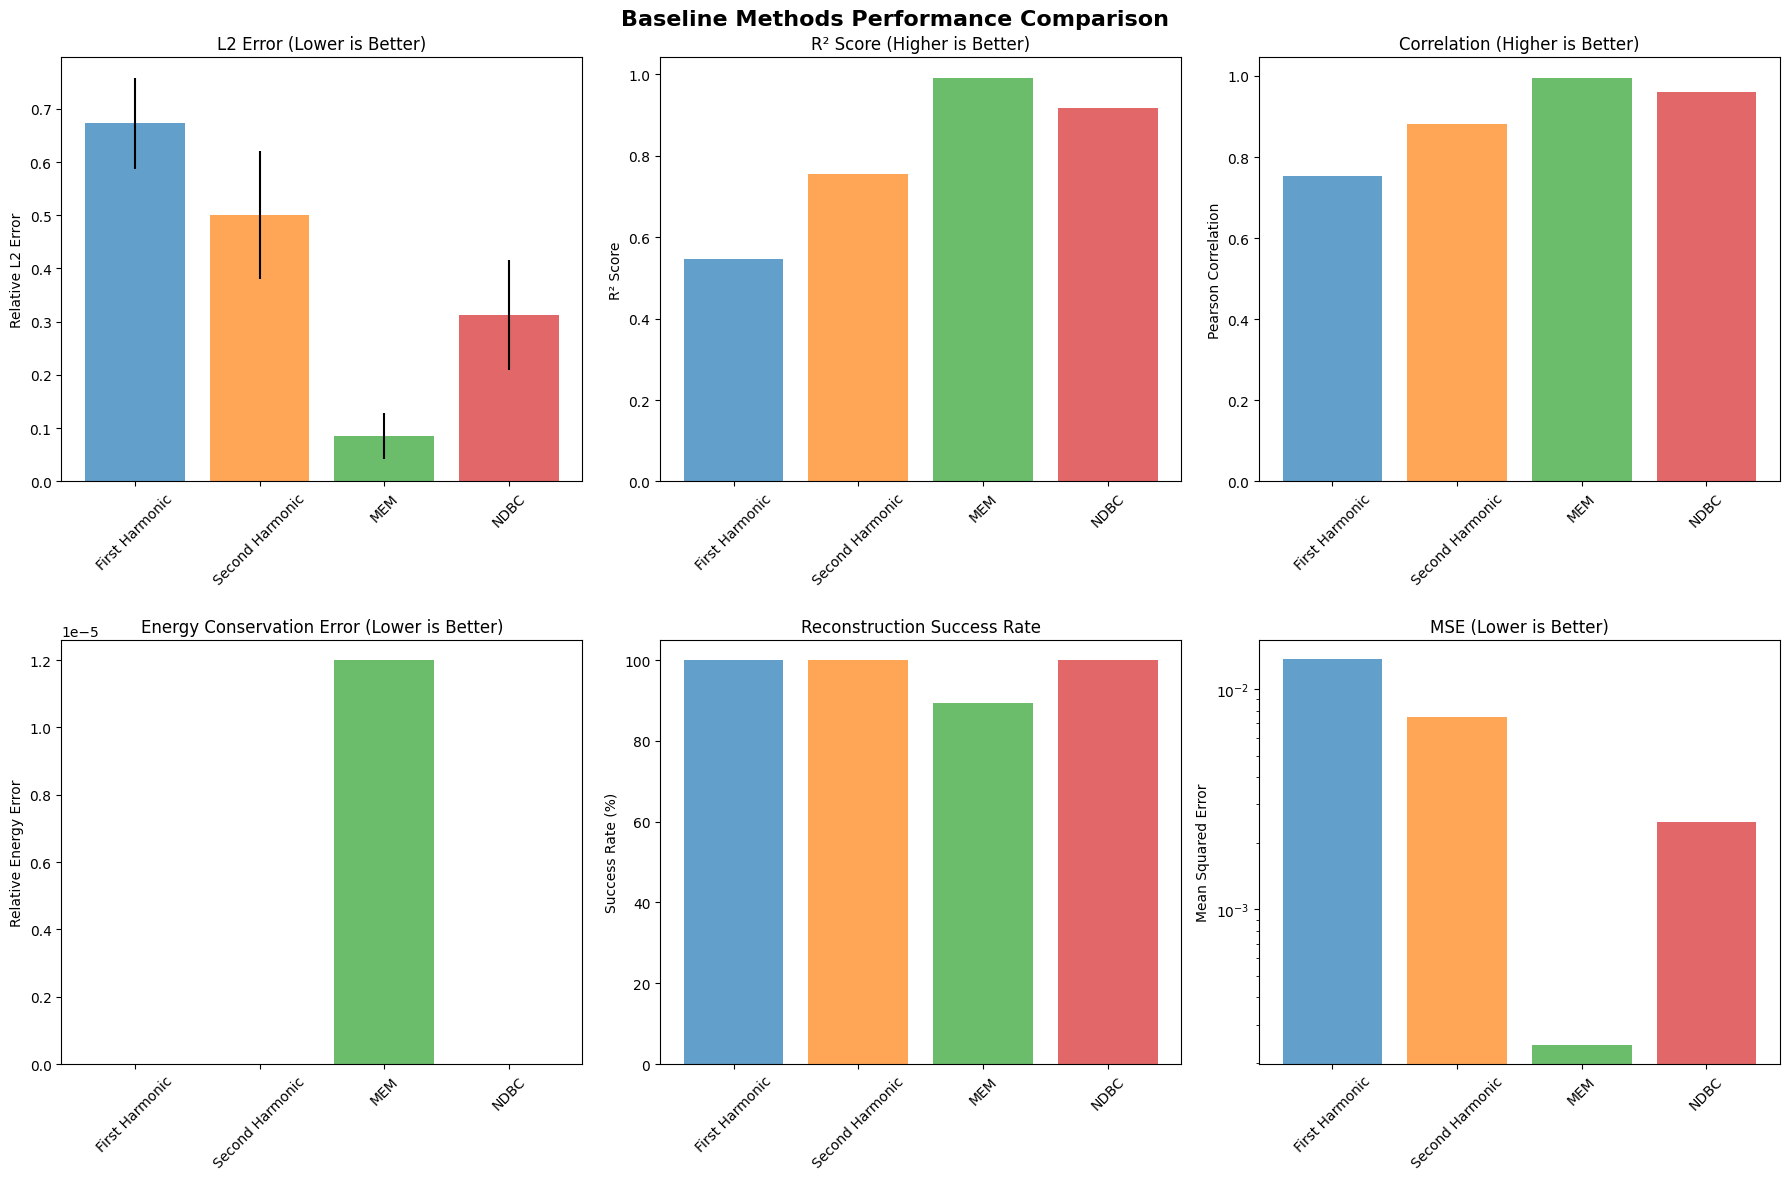

✅ Visualization completed!


In [14]:
# Create visualization comparing all methods
print("Creating baseline methods visualization...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Baseline Methods Performance Comparison', fontsize=16, fontweight='bold')

methods = results_df['method'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# L2 Error comparison
axes[0, 0].bar(methods, results_df['l2_error_mean'], yerr=results_df['l2_error_std'], 
               color=colors, alpha=0.7)
axes[0, 0].set_title('L2 Error (Lower is Better)')
axes[0, 0].set_ylabel('Relative L2 Error')
axes[0, 0].tick_params(axis='x', rotation=45)

# R² comparison
axes[0, 1].bar(methods, results_df['r2_score'], color=colors, alpha=0.7)
axes[0, 1].set_title('R² Score (Higher is Better)')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Correlation comparison
axes[0, 2].bar(methods, results_df['correlation'], color=colors, alpha=0.7)
axes[0, 2].set_title('Correlation (Higher is Better)')
axes[0, 2].set_ylabel('Pearson Correlation')
axes[0, 2].tick_params(axis='x', rotation=45)

# Energy conservation
axes[1, 0].bar(methods, results_df['energy_conservation_error'], color=colors, alpha=0.7)
axes[1, 0].set_title('Energy Conservation Error (Lower is Better)')
axes[1, 0].set_ylabel('Relative Energy Error')
axes[1, 0].tick_params(axis='x', rotation=45)

# Success rates
axes[1, 1].bar(methods, [x*100 for x in results_df['reconstruction_success_rate']], 
               color=colors, alpha=0.7)
axes[1, 1].set_title('Reconstruction Success Rate')
axes[1, 1].set_ylabel('Success Rate (%)')
axes[1, 1].set_ylim(0, 105)
axes[1, 1].tick_params(axis='x', rotation=45)

# MSE comparison
axes[1, 2].bar(methods, results_df['mse'], color=colors, alpha=0.7)
axes[1, 2].set_title('MSE (Lower is Better)')
axes[1, 2].set_ylabel('Mean Squared Error')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_yscale('log')  # Log scale for MSE

plt.tight_layout()
plt.show()

print("✅ Visualization completed!")

Creating sample reconstruction comparison...
Sample reconstruction at time step 4752, frequency bin 10


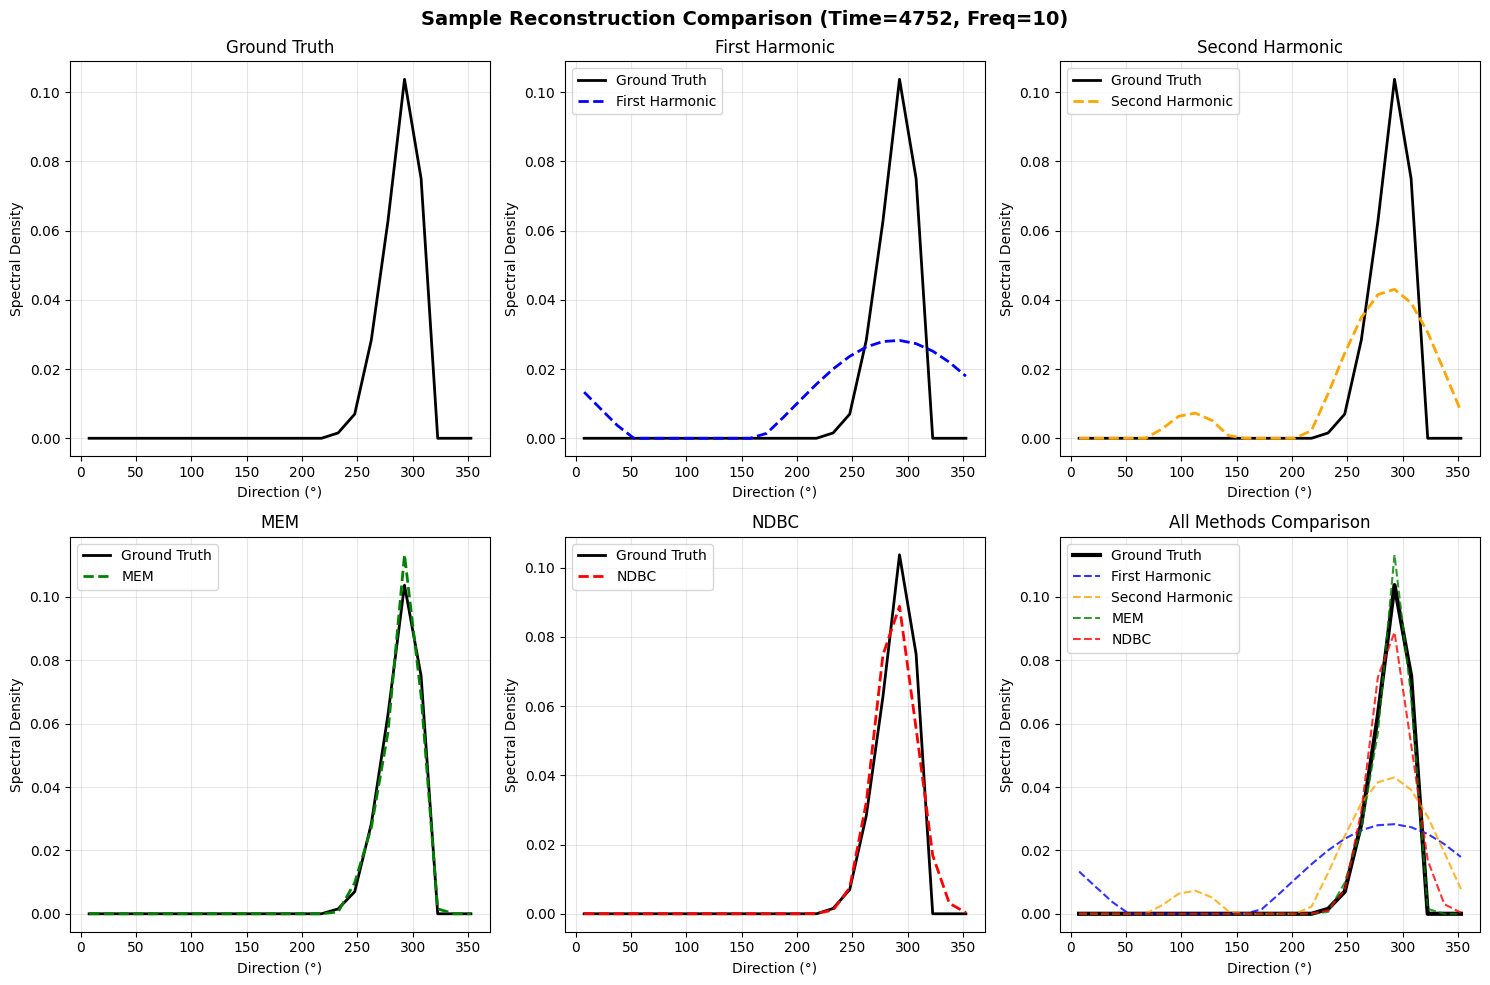


✅ Sample reconstruction comparison completed!


In [15]:
# Show sample reconstructions for visual comparison
print("Creating sample reconstruction comparison...")

# Select a representative sample (middle of dataset)
sample_idx = n_time // 2
sample_freq = 10  # Middle frequency bin

print(f"Sample reconstruction at time step {sample_idx}, frequency bin {sample_freq}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Sample Reconstruction Comparison (Time={sample_idx}, Freq={sample_freq})', 
             fontsize=14, fontweight='bold')

# Ground truth
axes[0, 0].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=2, label='Ground Truth')
axes[0, 0].set_title('Ground Truth')
axes[0, 0].set_xlabel('Direction (°)')
axes[0, 0].set_ylabel('Spectral Density')
axes[0, 0].grid(True, alpha=0.3)

# First Harmonic
axes[0, 1].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=2, label='Ground Truth')
axes[0, 1].plot(direction_deg, S_first_harmonic[sample_idx, sample_freq, :], 'b--', linewidth=2, label='First Harmonic')
axes[0, 1].set_title('First Harmonic')
axes[0, 1].set_xlabel('Direction (°)')
axes[0, 1].set_ylabel('Spectral Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Second Harmonic
axes[0, 2].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=2, label='Ground Truth')
axes[0, 2].plot(direction_deg, S_second_harmonic[sample_idx, sample_freq, :], 'orange', linestyle='--', linewidth=2, label='Second Harmonic')
axes[0, 2].set_title('Second Harmonic')
axes[0, 2].set_xlabel('Direction (°)')
axes[0, 2].set_ylabel('Spectral Density')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# MEM
axes[1, 0].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=2, label='Ground Truth')
axes[1, 0].plot(direction_deg, S_mem[sample_idx, sample_freq, :], 'g--', linewidth=2, label='MEM')
axes[1, 0].set_title('MEM')
axes[1, 0].set_xlabel('Direction (°)')
axes[1, 0].set_ylabel('Spectral Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# NDBC
axes[1, 1].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=2, label='Ground Truth')
axes[1, 1].plot(direction_deg, S_ndbc[sample_idx, sample_freq, :], 'r--', linewidth=2, label='NDBC')
axes[1, 1].set_title('NDBC')
axes[1, 1].set_xlabel('Direction (°)')
axes[1, 1].set_ylabel('Spectral Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# All methods overlay
axes[1, 2].plot(direction_deg, S2D_true[sample_idx, sample_freq, :], 'k-', linewidth=3, label='Ground Truth')
axes[1, 2].plot(direction_deg, S_first_harmonic[sample_idx, sample_freq, :], 'b--', linewidth=1.5, alpha=0.8, label='First Harmonic')
axes[1, 2].plot(direction_deg, S_second_harmonic[sample_idx, sample_freq, :], 'orange', linestyle='--', linewidth=1.5, alpha=0.8, label='Second Harmonic')
axes[1, 2].plot(direction_deg, S_mem[sample_idx, sample_freq, :], 'g--', linewidth=1.5, alpha=0.8, label='MEM')
axes[1, 2].plot(direction_deg, S_ndbc[sample_idx, sample_freq, :], 'r--', linewidth=1.5, alpha=0.8, label='NDBC')
axes[1, 2].set_title('All Methods Comparison')
axes[1, 2].set_xlabel('Direction (°)')
axes[1, 2].set_ylabel('Spectral Density')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Sample reconstruction comparison completed!")

In [16]:
# Final comprehensive summary
print("=" * 80)
print("FINAL BASELINE EVALUATION SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Information:")
print(f"  Total samples: {n_time:,}")
print(f"  Frequency bins: {n_freq}")
print(f"  Direction bins: {n_dir}")
print(f"  Total spectrum points: {n_time * n_freq * n_dir:,}")

print(f"\n🏆 METHOD RANKING (by L2 Error, lower is better):")
ranked_methods = results_df.sort_values('l2_error_mean')
for i, (_, row) in enumerate(ranked_methods.iterrows(), 1):
    print(f"  {i}. {row['method']}: {row['l2_error_mean']:.6f} ± {row['l2_error_std']:.6f}")

print(f"\n📈 KEY FINDINGS:")
best_method = ranked_methods.iloc[0]
worst_method = ranked_methods.iloc[-1]

improvement = worst_method['l2_error_mean'] / best_method['l2_error_mean']
print(f"  • Best method: {best_method['method']} (L2: {best_method['l2_error_mean']:.6f})")
print(f"  • Worst method: {worst_method['method']} (L2: {worst_method['l2_error_mean']:.6f})")
print(f"  • Improvement factor: {improvement:.2f}x")

# Method complexity vs performance
complexity_order = ['First Harmonic', 'NDBC', 'Second Harmonic', 'MEM']
print(f"\n⚖️ COMPLEXITY vs PERFORMANCE:")
for method in complexity_order:
    if method in results_df['method'].values:
        row = results_df[results_df['method'] == method].iloc[0]
        print(f"  • {method}: R²={row['r2_score']:.4f}, Success={row['reconstruction_success_rate']*100:.1f}%")

print(f"\n💡 RECOMMENDATIONS:")
print(f"  • For best accuracy: Use {best_method['method']} (lowest error)")
highest_r2_method = results_df.loc[results_df['r2_score'].idxmax()]
print(f"  • For best fit: Use {highest_r2_method['method']} (R²={highest_r2_method['r2_score']:.4f})")
most_reliable = results_df.loc[results_df['reconstruction_success_rate'].idxmax()]
print(f"  • For reliability: Use {most_reliable['method']} (100% success rate)")
print(f"  • For simplicity: Use First Harmonic (good balance of accuracy/complexity)")

# Save results
results_df.to_csv('baseline_methods_comparison.csv', index=False)
print(f"\n💾 Results saved to: baseline_methods_comparison.csv")

print("\n" + "=" * 80)
print("🎉 BASELINE EVALUATION COMPLETED SUCCESSFULLY!")
print("=" * 80)

FINAL BASELINE EVALUATION SUMMARY

📊 Dataset Information:
  Total samples: 9,504
  Frequency bins: 30
  Direction bins: 24
  Total spectrum points: 6,842,880

🏆 METHOD RANKING (by L2 Error, lower is better):
  1. MEM: 0.085790 ± 0.042917
  2. NDBC: 0.312307 ± 0.103187
  3. Second Harmonic: 0.500382 ± 0.119873
  4. First Harmonic: 0.672530 ± 0.086168

📈 KEY FINDINGS:
  • Best method: MEM (L2: 0.085790)
  • Worst method: First Harmonic (L2: 0.672530)
  • Improvement factor: 7.84x

⚖️ COMPLEXITY vs PERFORMANCE:
  • First Harmonic: R²=0.5472, Success=100.0%
  • NDBC: R²=0.9172, Success=100.0%
  • Second Harmonic: R²=0.7539, Success=100.0%
  • MEM: R²=0.9919, Success=89.4%

💡 RECOMMENDATIONS:
  • For best accuracy: Use MEM (lowest error)
  • For best fit: Use MEM (R²=0.9919)
  • For reliability: Use First Harmonic (100% success rate)
  • For simplicity: Use First Harmonic (good balance of accuracy/complexity)

💾 Results saved to: baseline_methods_comparison.csv

🎉 BASELINE EVALUATION COMPLE

# 🌊 Evaluation on Independent Dataset

Evaluate all baseline methods on completely separate evaluation data to verify generalization performance.

In [13]:
# Load evaluation dataset
print("Loading evaluation dataset for baseline methods...")

eval_data_path = "eval_data\\processed_0\\era5_wave_eval.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data
    X_eval = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]
    y_eval = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    freq_hz_eval = eval_data["freq_hz"]
    direction_deg_eval = eval_data["direction_deg"]
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  X_eval shape: {X_eval.shape}")
    print(f"  y_eval shape: {y_eval.shape}")
    print(f"  Time steps: {X_eval.shape[0]}")
    print(f"  Frequency bins: {len(freq_hz_eval)}")
    print(f"  Direction bins: {len(direction_deg_eval)}")
    
    # Extract components from evaluation data
    S1D_eval = X_eval[:, 0, :]  # 1D spectrum: (time, 30)
    a1_eval = X_eval[:, 1, :]   # First harmonic a1: (time, 30)
    b1_eval = X_eval[:, 2, :]   # First harmonic b1: (time, 30)
    a2_eval = X_eval[:, 3, :]   # Second harmonic a2: (time, 30)
    b2_eval = X_eval[:, 4, :]   # Second harmonic b2: (time, 30)
    S2D_eval_true = y_eval      # 2D spectra: (time, 30, 24)
    
    print(f"  S1D_eval: {S1D_eval.shape}")
    print(f"  S2D_eval_true: {S2D_eval_true.shape}")
    
    # Check for NaN values
    print(f"  NaN values in X_eval: {np.isnan(X_eval).sum()}")
    print(f"  NaN values in y_eval: {np.isnan(y_eval).sum()}")
    
    # Setup evaluation parameters for this dataset
    eval_direction_rad = np.deg2rad(direction_deg_eval)
    eval_ddir = np.deg2rad(15.0)  # 15° spacing
    
    print(f"\n✅ Evaluation dataset ready: {S1D_eval.shape[0]} samples")

Loading evaluation dataset for baseline methods...
✅ Evaluation data loaded successfully
  X_eval shape: (1416, 5, 30)
  y_eval shape: (1416, 30, 24)
  Time steps: 1416
  Frequency bins: 30
  Direction bins: 24
  S1D_eval: (1416, 30)
  S2D_eval_true: (1416, 30, 24)
  NaN values in X_eval: 0
  NaN values in y_eval: 0

✅ Evaluation dataset ready: 1416 samples


In [14]:
# Apply all baseline methods to evaluation data
if 'X_eval' in locals():
    print("Applying all baseline methods to evaluation data...")
    
    # 1. First Harmonic Method
    print("  Computing First Harmonic reconstruction...")
    S_eval_first_harmonic = compute_first_harmonic_spectrum(
        S1D_eval, a1_eval, b1_eval, eval_direction_rad, eval_ddir
    )
    
    # 2. Second Harmonic Method
    print("  Computing Second Harmonic reconstruction...")
    S_eval_second_harmonic = compute_second_harmonic_spectrum(
        S1D_eval, a1_eval, b1_eval, a2_eval, b2_eval, eval_direction_rad, eval_ddir
    )
    
    # 3. MEM Method
    print("  Computing MEM reconstruction...")
    n_eval_time, n_eval_freq, n_eval_dir = S2D_eval_true.shape
    S_eval_mem = np.zeros((n_eval_time, n_eval_freq, n_eval_dir))
    
    eval_solved_cases = 0
    eval_total_cases = n_eval_time * n_eval_freq
    
    for t in range(n_eval_time):
        if t % 10 == 0:
            print(f"    Processing evaluation time step {t}/{n_eval_time}")
        
        for f in range(n_eval_freq):
            S_f_val = S1D_eval[t, f]
            a1_val = a1_eval[t, f]
            b1_val = b1_eval[t, f]
            a2_val = a2_eval[t, f]
            b2_val = b2_eval[t, f]
            
            if S_f_val > 1e-15:
                lambdas, D, success = solve_mem_parameters(
                    a1_val, b1_val, a2_val, b2_val, 
                    eval_direction_rad, eval_ddir
                )
                
                if success:
                    eval_solved_cases += 1
            else:
                D = np.ones(n_eval_dir) / n_eval_dir
            
            S_eval_mem[t, f, :] = S_f_val * D
    
    print(f"    MEM solved: {eval_solved_cases}/{eval_total_cases} ({100*eval_solved_cases/eval_total_cases:.1f}%)")
    
    # 4. NDBC Method
    print("  Computing NDBC reconstruction...")
    S_eval_ndbc = compute_ndbc_spectrum(
        S1D_eval, a1_eval, b1_eval, eval_direction_rad, eval_ddir
    )
    
    print(f"\n✅ All baseline methods applied to evaluation data")
    print(f"  Evaluation dataset shape: {S2D_eval_true.shape}")
    print(f"  All reconstructions computed successfully")
    
else:
    print("❌ Evaluation data not loaded. Run previous cell first.")

Applying all baseline methods to evaluation data...
  Computing First Harmonic reconstruction...
  Computing Second Harmonic reconstruction...
  Computing MEM reconstruction...
    Processing evaluation time step 0/1416
    Processing evaluation time step 10/1416
    Processing evaluation time step 20/1416
    Processing evaluation time step 30/1416
    Processing evaluation time step 40/1416
    Processing evaluation time step 50/1416
    Processing evaluation time step 60/1416
    Processing evaluation time step 70/1416
    Processing evaluation time step 80/1416
    Processing evaluation time step 90/1416
    Processing evaluation time step 100/1416
    Processing evaluation time step 110/1416
    Processing evaluation time step 120/1416
    Processing evaluation time step 130/1416
    Processing evaluation time step 140/1416
    Processing evaluation time step 150/1416
    Processing evaluation time step 160/1416
    Processing evaluation time step 170/1416
    Processing evaluatio

In [15]:
# Compute evaluation metrics for all baseline methods
if 'S_eval_first_harmonic' in locals():
    print("Computing evaluation metrics for all baseline methods...")
    
    # Flatten spectra for R-squared calculations
    y_eval_true_flat = S2D_eval_true.flatten()
    
    # Initialize evaluation results
    eval_results = {
        'method': [],
        'r2_score': [],
        'mse': [],
        'mae': [],
        'correlation': []
    }
    
    methods_eval = [
        ('First Harmonic', S_eval_first_harmonic),
        ('Second Harmonic', S_eval_second_harmonic),
        ('MEM', S_eval_mem),
        ('NDBC', S_eval_ndbc)
    ]
    
    print(f"\n📊 EVALUATION RESULTS ON INDEPENDENT DATASET:")
    print("="*60)
    
    for method_name, S_pred in methods_eval:
        # Clean predictions
        S_pred_clean = np.nan_to_num(S_pred, nan=0.0)
        S_pred_flat = S_pred_clean.flatten()
        
        # Compute metrics
        r2 = r2_score(y_eval_true_flat, S_pred_flat)
        mse = np.mean((S_pred_clean - S2D_eval_true) ** 2)
        mae = np.mean(np.abs(S_pred_clean - S2D_eval_true))
        correlation = np.corrcoef(y_eval_true_flat, S_pred_flat)[0, 1]
        
        # Store results
        eval_results['method'].append(method_name)
        eval_results['r2_score'].append(r2)
        eval_results['mse'].append(mse)
        eval_results['mae'].append(mae)
        eval_results['correlation'].append(correlation)
        
        # Print results
        print(f"{method_name:15s}: R² = {r2:.6f}, MSE = {mse:.6e}, Correlation = {correlation:.6f}")
    
    # Create evaluation DataFrame
    eval_df = pd.DataFrame(eval_results)
    
    # Find best method
    best_eval_method = eval_df.loc[eval_df['r2_score'].idxmax(), 'method']
    best_eval_r2 = eval_df.loc[eval_df['r2_score'].idxmax(), 'r2_score']
    
    print("="*60)
    print(f"🏆 BEST METHOD ON EVALUATION DATA: {best_eval_method} (R² = {best_eval_r2:.6f})")
    print("="*60)
    
else:
    print("❌ Baseline reconstructions not available. Run previous cell first.")

Computing evaluation metrics for all baseline methods...

📊 EVALUATION RESULTS ON INDEPENDENT DATASET:
First Harmonic : R² = 0.551659, MSE = 8.421527e-01, Correlation = 0.757278
Second Harmonic: R² = 0.775299, MSE = 4.220731e-01, Correlation = 0.896598
MEM            : R² = 0.995470, MSE = 8.508271e-03, Correlation = 0.997733
NDBC           : R² = 0.961214, MSE = 7.285458e-02, Correlation = 0.982182
🏆 BEST METHOD ON EVALUATION DATA: MEM (R² = 0.995470)


Visualizing 3 example reconstructions on evaluation data...

Example 1 (Index 354):
  First Harmonic: R² = 0.624748
  Second Harmonic: R² = 0.819829
  MEM: R² = 0.991781
  NDBC: R² = 0.872676

Example 2 (Index 708):
  First Harmonic: R² = 0.701908
  Second Harmonic: R² = 0.893337
  MEM: R² = 0.988785
  NDBC: R² = 0.931052

Example 3 (Index 1062):
  First Harmonic: R² = 0.700235
  Second Harmonic: R² = 0.888147
  MEM: R² = 0.983326
  NDBC: R² = 0.915804


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16016\1421048593.py:57: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\projects\ocnwvs\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


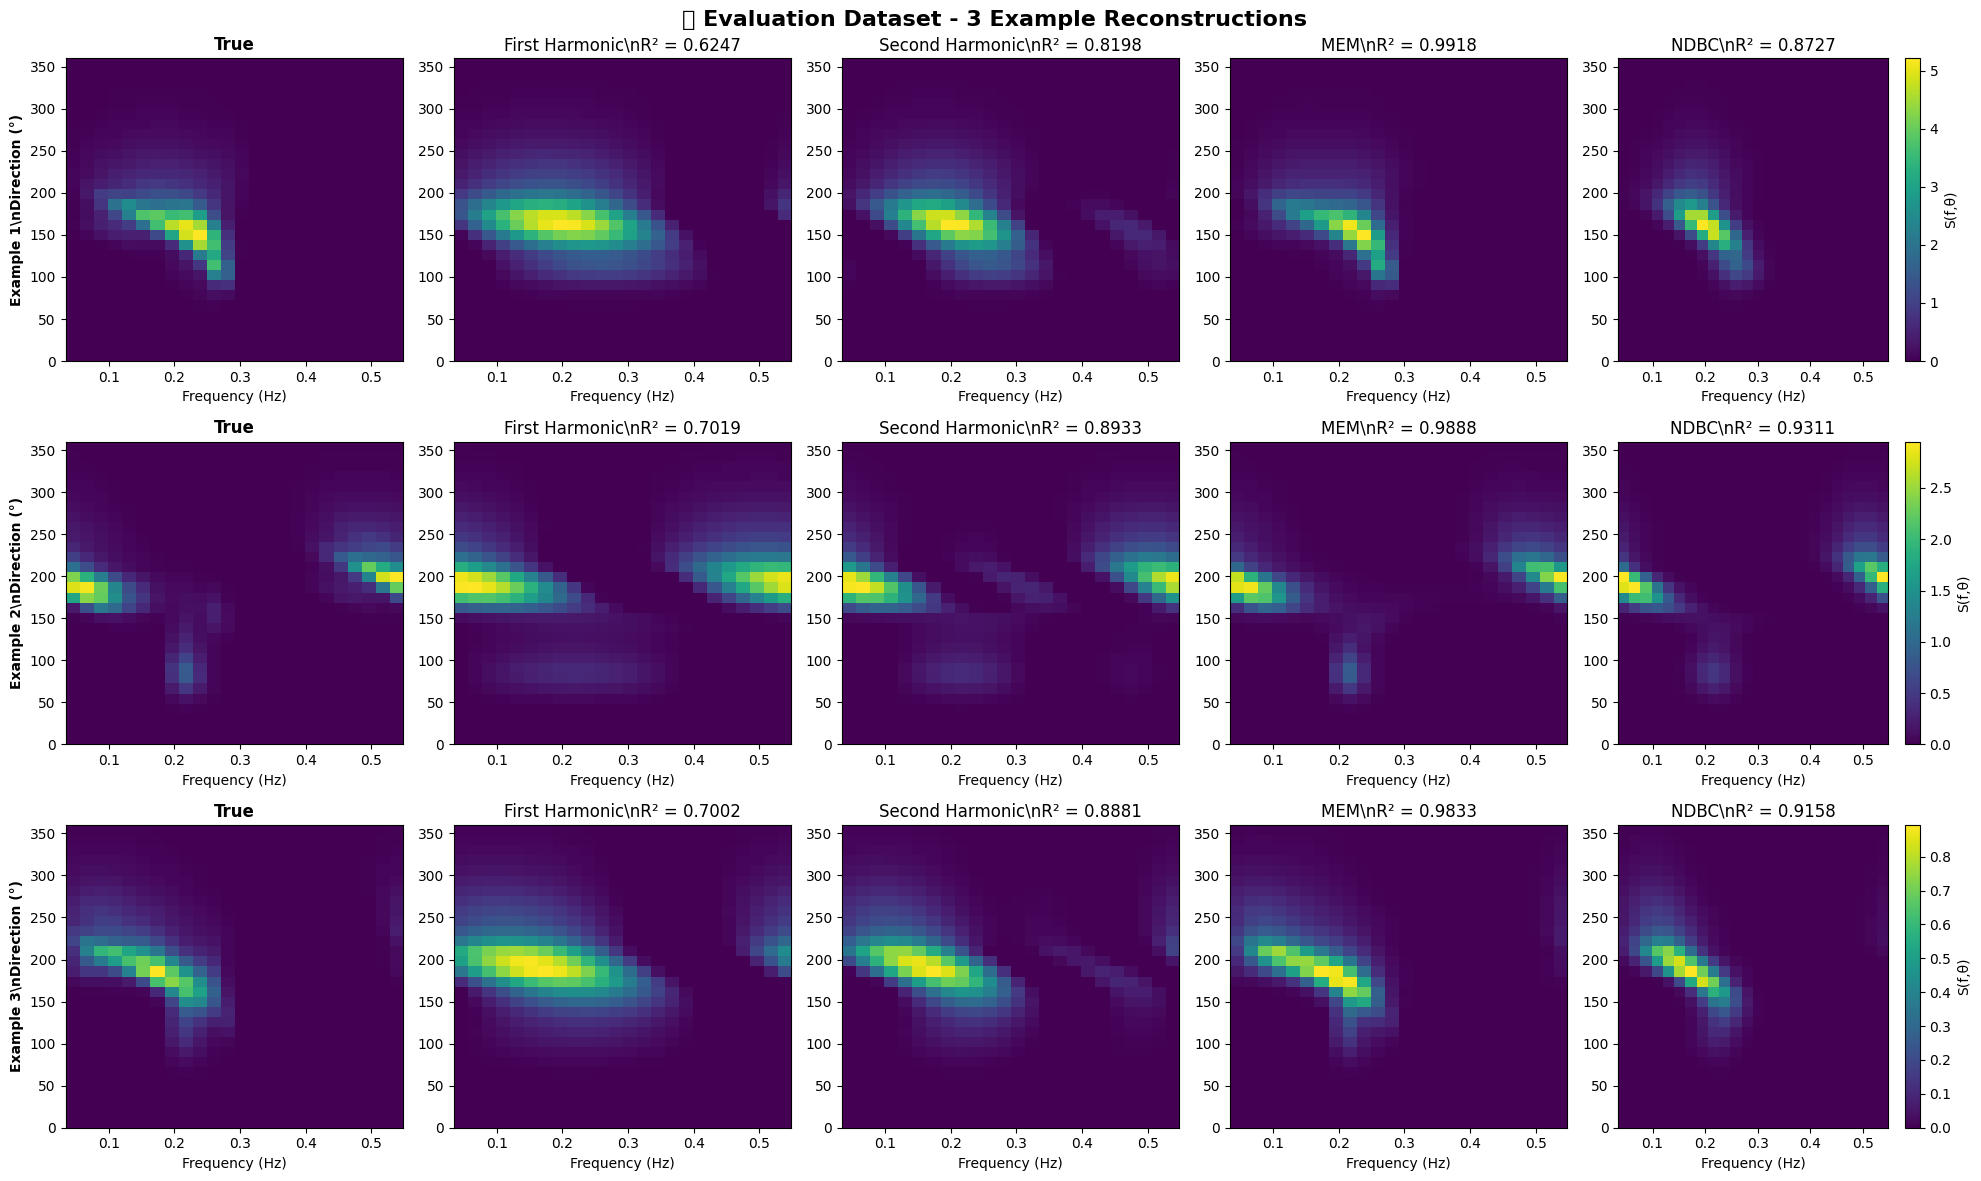


📋 EVALUATION SUMMARY TABLE:
         Method  R² Score      MSE  Correlation
 First Harmonic  0.551659 0.842153     0.757278
Second Harmonic  0.775299 0.422073     0.896598
            MEM  0.995470 0.008508     0.997733
           NDBC  0.961214 0.072855     0.982182


In [16]:
# Visualize 3 example reconstructions on evaluation data
if 'S_eval_first_harmonic' in locals() and 'eval_df' in locals():
    print("Visualizing 3 example reconstructions on evaluation data...")
    
    # Select 3 diverse examples from evaluation dataset
    np.random.seed(42)  # For reproducible examples
    n_eval = S2D_eval_true.shape[0]
    example_indices = [
        n_eval // 4,           # First quarter
        n_eval // 2,           # Middle
        3 * n_eval // 4        # Third quarter
    ]
    
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    fig.suptitle('🌊 Evaluation Dataset - 3 Example Reconstructions', fontsize=16, fontweight='bold')
    
    methods_vis = [
        ('True', S2D_eval_true),
        ('First Harmonic', S_eval_first_harmonic),
        ('Second Harmonic', S_eval_second_harmonic), 
        ('MEM', S_eval_mem),
        ('NDBC', S_eval_ndbc)
    ]
    
    for row, idx in enumerate(example_indices):
        print(f"\nExample {row+1} (Index {idx}):")
        
        # Compute R² for this specific example
        true_spectrum = S2D_eval_true[idx].flatten()
        
        for col, (method_name, S_pred) in enumerate(methods_vis):
            ax = axes[row, col]
            
            if method_name == 'True':
                spectrum = S2D_eval_true[idx]
                ax.set_ylabel(f'Example {row+1}\\nDirection (°)', fontweight='bold')
                r2_text = ""
            else:
                spectrum = np.nan_to_num(S_pred[idx], nan=0.0)
                pred_flat = spectrum.flatten()
                r2 = r2_score(true_spectrum, pred_flat)
                r2_text = f"\\nR² = {r2:.4f}"
                print(f"  {method_name}: R² = {r2:.6f}")
            
            # Plot spectrum
            im = ax.imshow(spectrum, aspect='auto', origin='lower', 
                          extent=[freq_hz_eval[0], freq_hz_eval[-1], 0, 360], 
                          cmap='viridis', vmin=0)
            
            ax.set_title(f'{method_name}{r2_text}', fontweight='bold' if method_name == 'True' else 'normal')
            ax.set_xlabel('Frequency (Hz)')
            
            # Add colorbar for rightmost plots
            if col == 4:
                plt.colorbar(im, ax=ax, label='S(f,θ)')
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print(f"\n📋 EVALUATION SUMMARY TABLE:")
    print("="*70)
    eval_display = eval_df[['method', 'r2_score', 'mse', 'correlation']].copy()
    eval_display['r2_score'] = eval_display['r2_score'].round(6)
    eval_display['mse'] = eval_display['mse'].round(8)
    eval_display['correlation'] = eval_display['correlation'].round(6)
    eval_display.columns = ['Method', 'R² Score', 'MSE', 'Correlation']
    print(eval_display.to_string(index=False))
    print("="*70)
    
else:
    print("❌ Evaluation results not available. Run previous cells first.")